In [89]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt
from os import listdir
from pathlib import Path
from scipy.signal import convolve

new_rc_params = {'text.usetex': False,
"svg.fonttype": 'none'
}
plt.rcParams.update(new_rc_params)

In [10]:
def load_spiking_data(directory, population, var_of_interest):
    neural_act = []
    stim_id = []
    for f in listdir('./neural_activity/Scale1/' + directory + population + var_of_interest):
        neural_act.append(np.genfromtxt('./neural_activity/Scale1/' + directory + population + var_of_interest + '/' + f, delimiter=','))
        stim_id.append(Path(f).stem)
    neural_act = np.asarray(neural_act)
    return neural_act, stim_id

In [11]:
def compute_nb_spike_per_neuron(data, popsize):
    data = np.asarray(data, dtype=int)
    spike_per_neuron = np.zeros(popsize)
    for i in np.unique(data):
        spike_per_neuron[i] = np.sum(np.where(data == i, 1, 0))

    return spike_per_neuron

In [76]:
def compute_spontaneous_activity(spike_times, duration):
    spontaneous_activity = np.zeros(duration)
    spike_times = np.asarray(spike_times, dtype=int)
    for i in range(duration):
        spontaneous_activity[i] = sum(spike_times==i)
    return spontaneous_activity

In [12]:
def load_data(directory):
    torques = []
    stim_id = []
    for f in listdir(directory):
        torques.append(np.genfromtxt(directory + '/' + f, delimiter=','))
        stim_id.append(Path(f).stem)
    torques = np.asarray(torques)
    return torques, stim_id

In [13]:
def compute_amplitude(torques):
    amplitude = []
    for i in range(len(torques)):
        amplitude.append(np.sqrt(torques[i][1]**2 + torques[i][2]**2))
    return np.asarray(amplitude)

def compute_amplitude_ONOFF(amplitude, th):
    amplitude_ONOFF = np.zeros(len(amplitude))
    th_reached = np.argwhere(amplitude > th)
    amplitude_ONOFF[th_reached[0][0]:th_reached[-1][0]] += 1
    return amplitude_ONOFF

def compute_direction(direction, amplitude):
    direction_array = np.ones(len(amplitude)) * direction
    return direction_array

In [14]:
def filter_signal_hanning(signal, window_size):
    """
    Filters a signal using a Hanning window.

    Parameters:
        signal (array-like): The input signal to be filtered.
        window_size (int): The size of the Hanning window. Should be an odd number.

    Returns:
        filtered_signal (numpy.ndarray): The filtered signal.
    """
    if window_size % 2 == 0:
        raise ValueError("window_size must be an odd number to ensure proper filtering.")
    
    # Create a Hanning window
    hanning_window = np.hanning(window_size)
    
    # Normalize the window to ensure signal amplitude is preserved
    hanning_window /= hanning_window.sum()
    
    # Apply the window to the signal using convolution
    filtered_signal = convolve(signal, hanning_window, mode='same')
    
    return filtered_signal



WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return array(a, dtype, copy=False, order=order)
 [py.warnings]
WARNING    c:\ProgramData\Anaconda3\envs\BRAIN_FOR_BRIAN\lib\site-packages\numpy\core\_asarray.py:102: VisibleDeprecationWarning: Cr

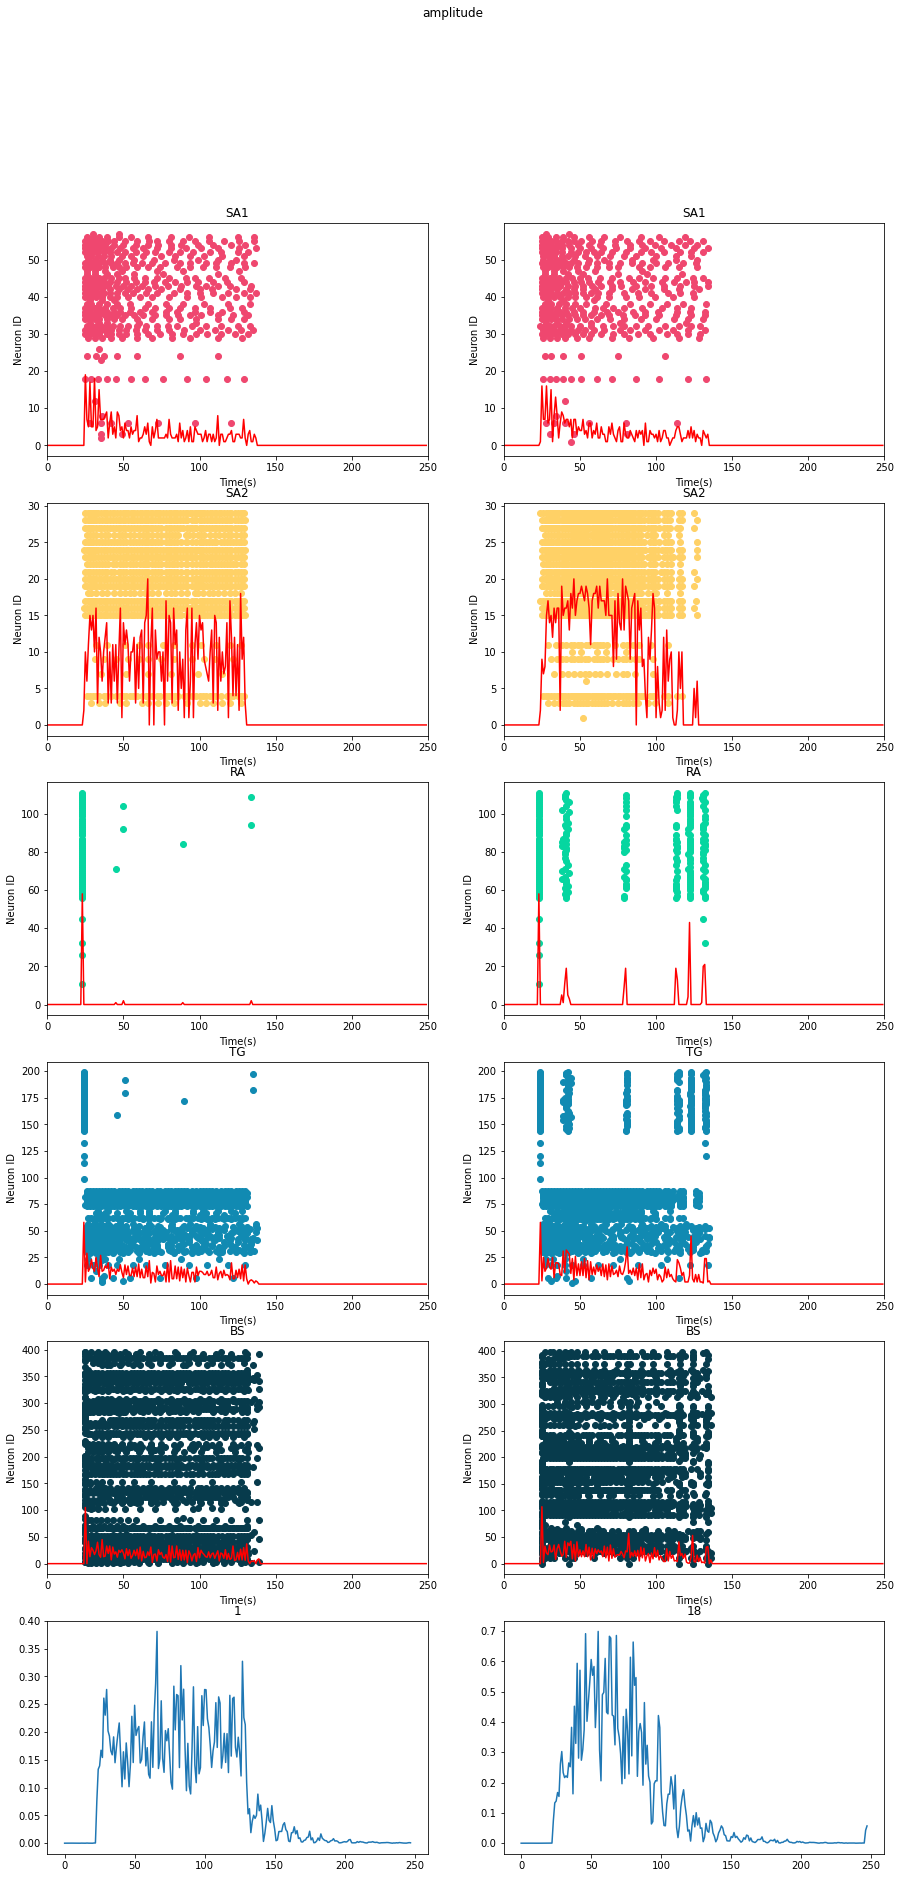

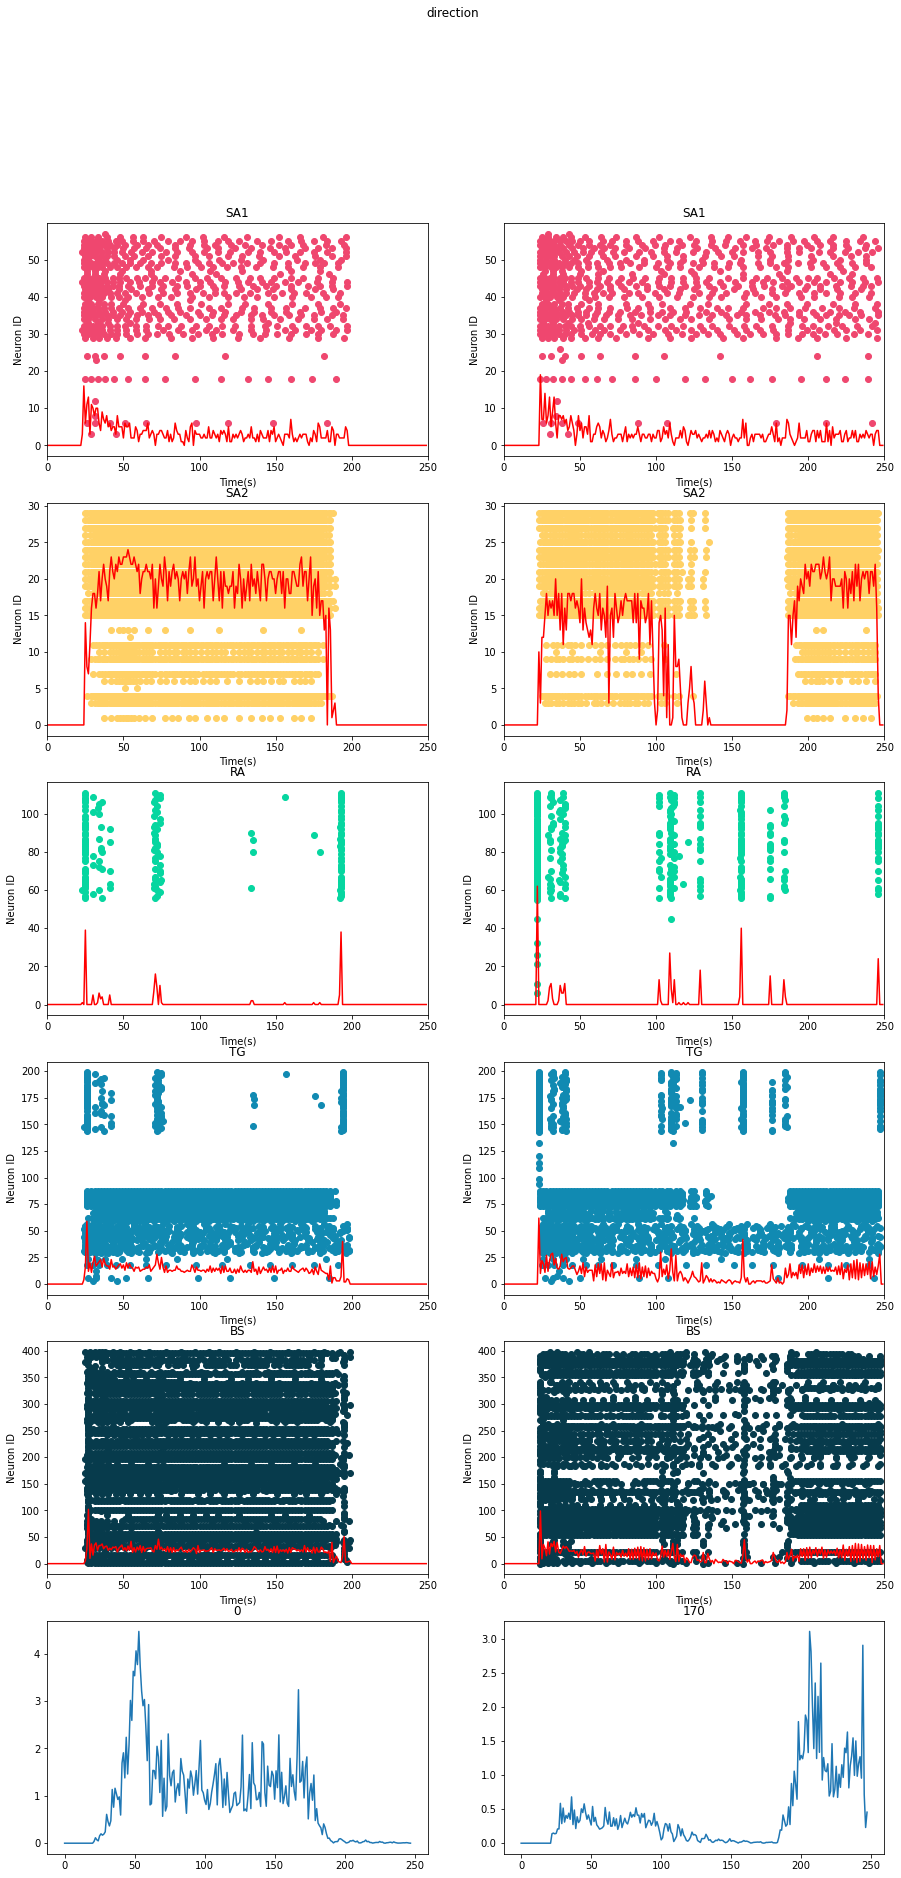

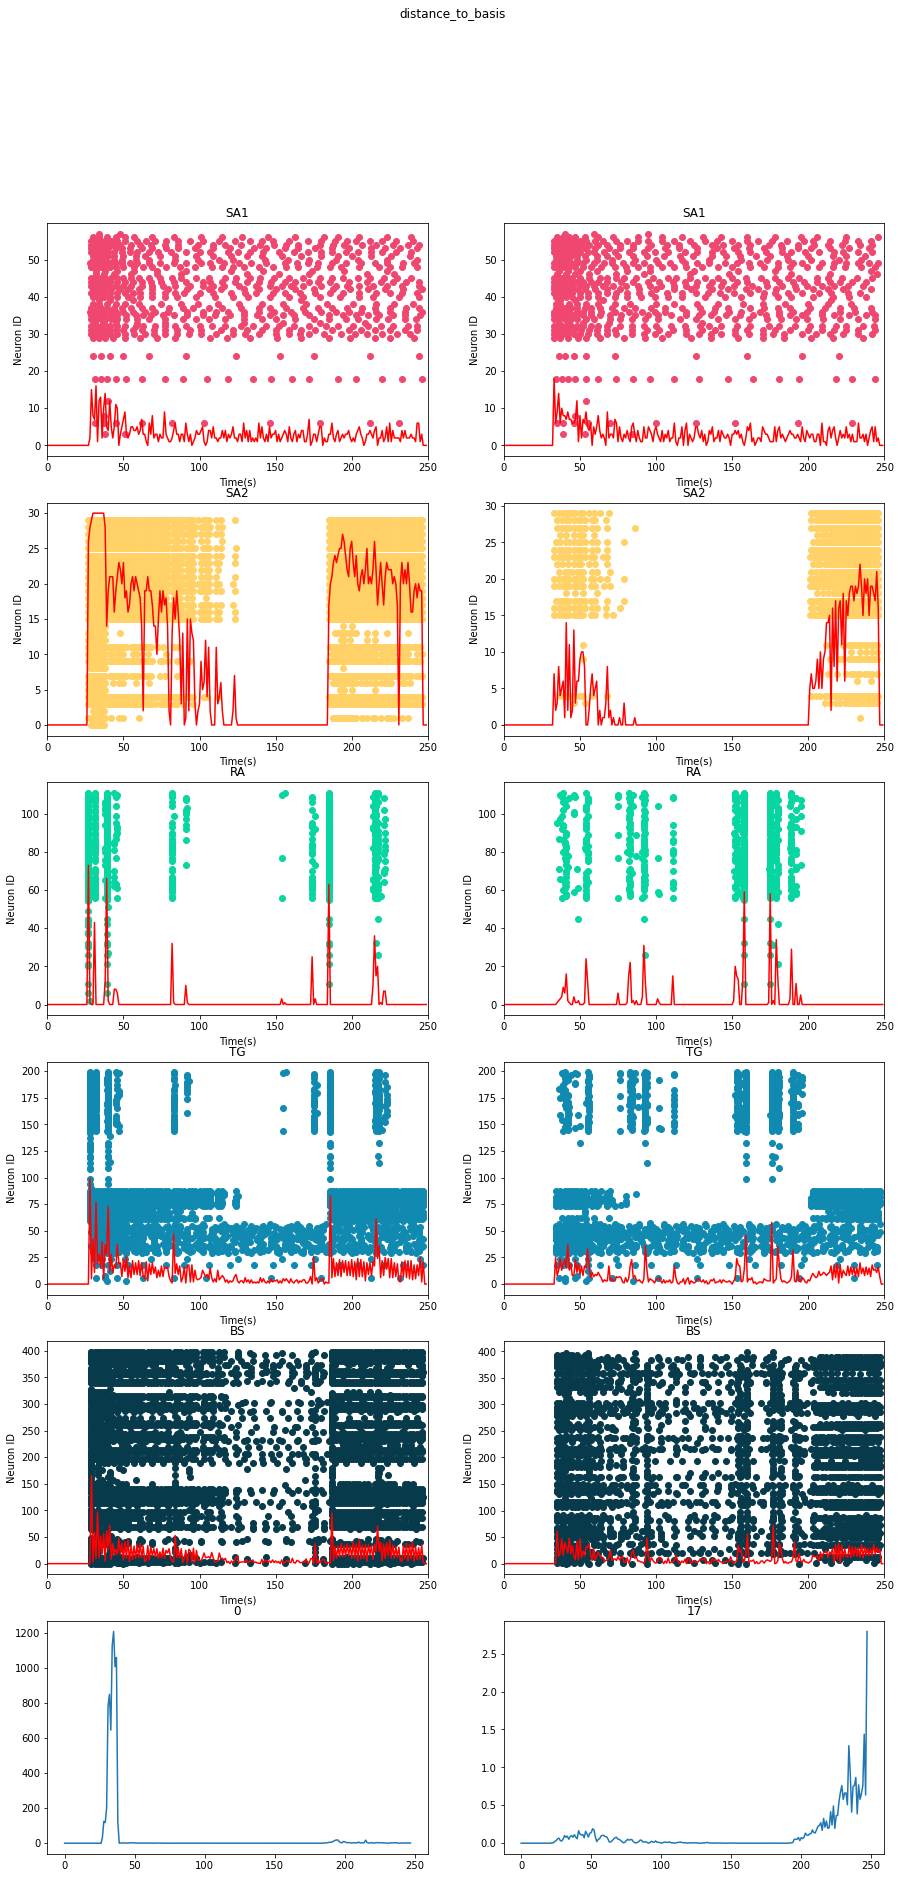

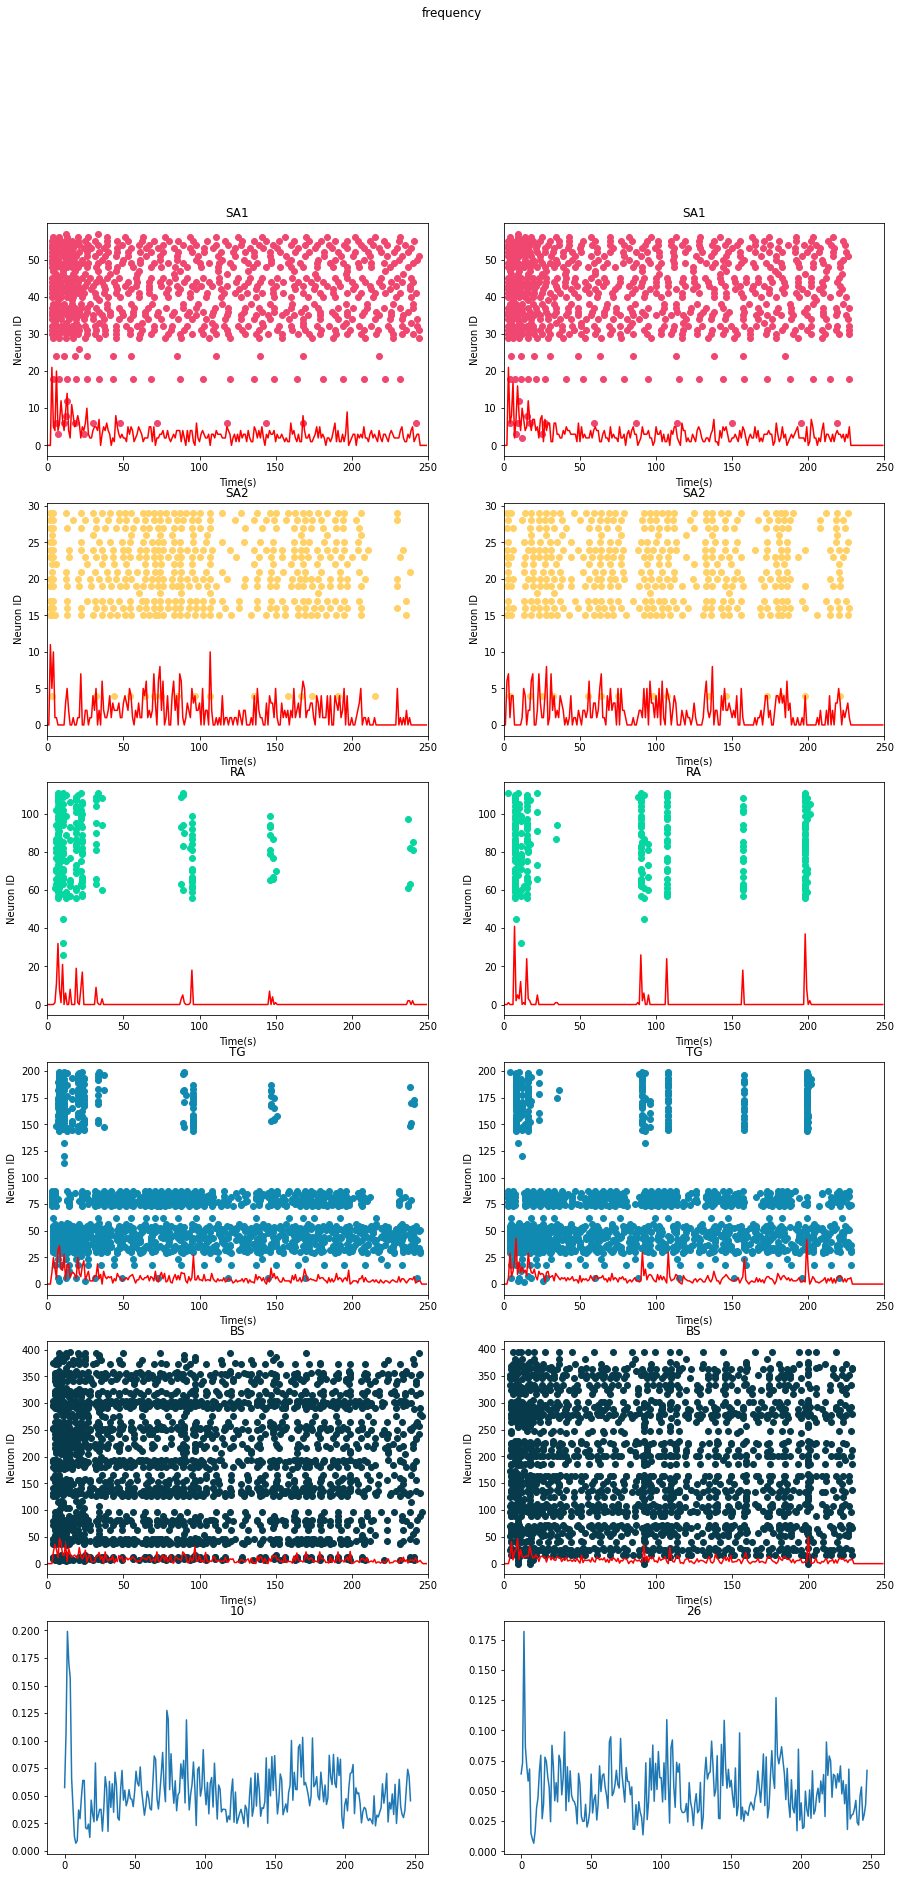

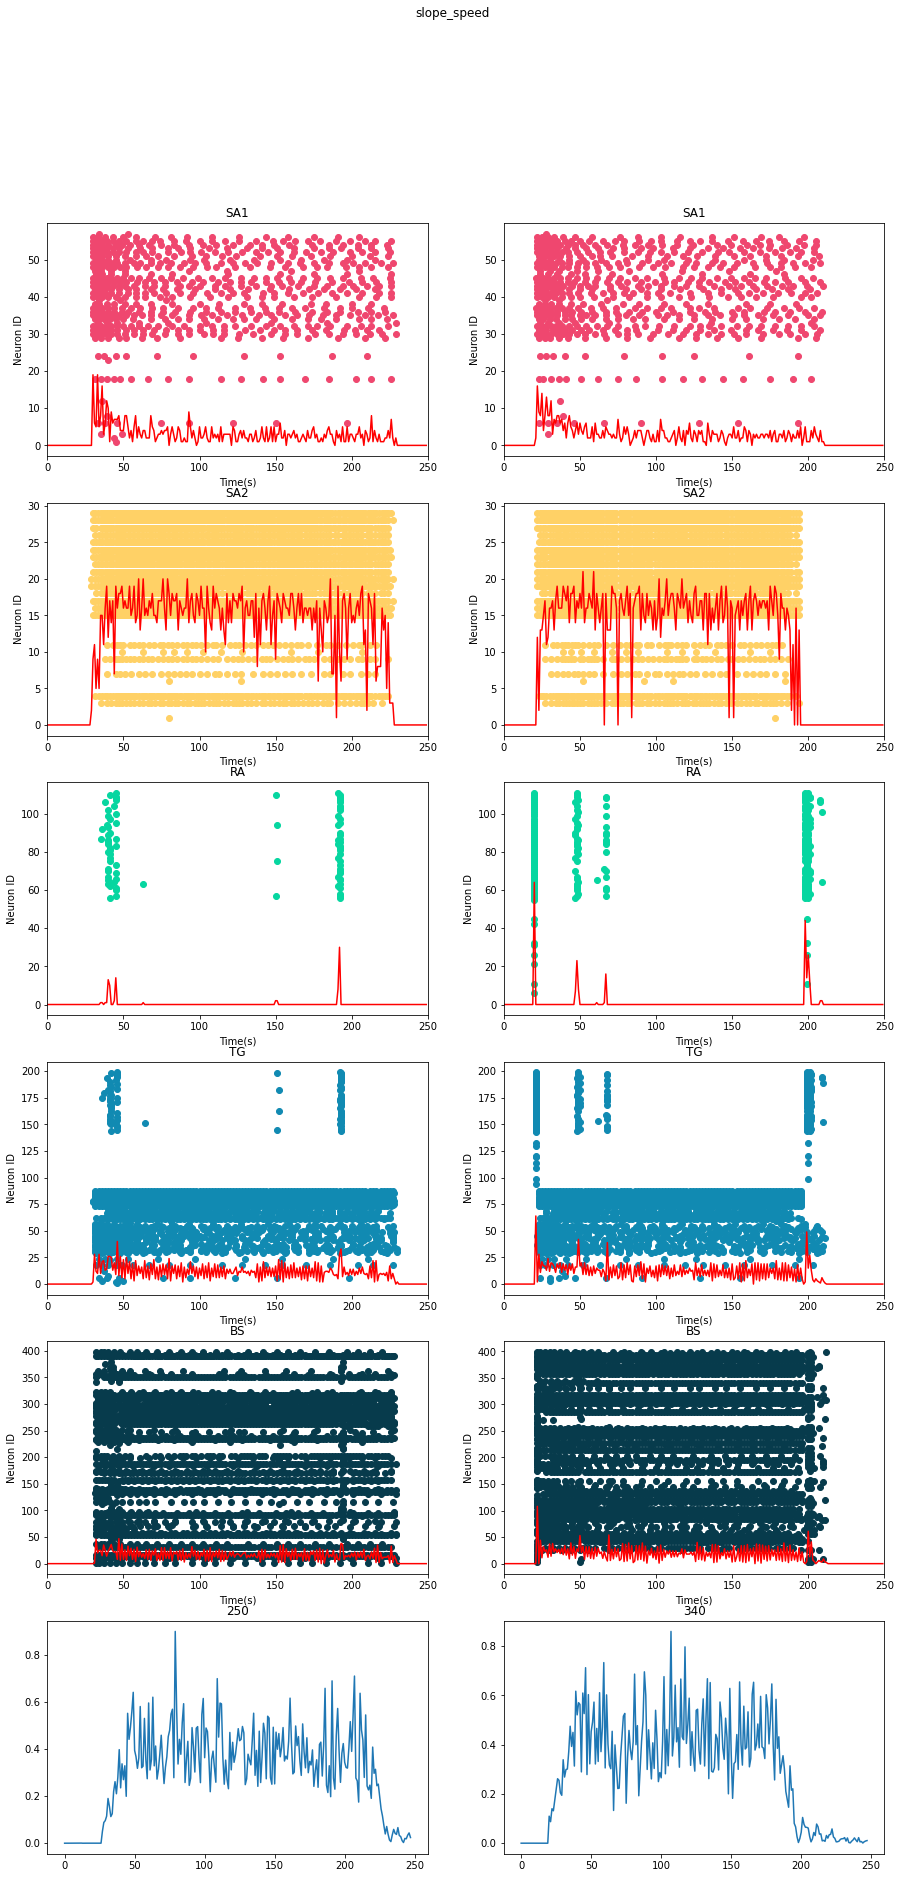

In [90]:
stimuli = ['0_amplitude', '0_direction', '0_distance_to_basis', '0_frequency', '0_slope_speed']
Populations = ['SA1', 'SA2', 'RA', 'TG', 'BS']
Colors = ['#ef476f', '#ffd166', '#06d6a0', '#118ab2', '#073b4c']
idx_low = 0
idx_high = 9
for s in stimuli:
    fig, axs = plt.subplots(6, 2, figsize=(15, 30))
    fig.suptitle(s[2:])
    torques, stim_id = load_data('./' + s + '/Moments')

    for idx, pop in enumerate(Populations):
        sp_time, _ = load_spiking_data(s + '/', pop + '/', 'spike_time')
        sp_id, _ = load_spiking_data(s + '/', pop + '/', 'spike_id')
        axs[idx, 0].scatter(sp_time[idx_low] * 1000, sp_id[idx_low], color=Colors[idx], alpha=1)
        rate1 = compute_spontaneous_activity(sp_time[idx_low] * 1000, 250)
        axs[idx, 0].plot(rate1, color = 'red')
        axs[idx, 0].set_xlim([0, 250])
        axs[idx, 0].set_title(pop)
        axs[idx, 0].set_xlabel('Time(s)')
        axs[idx, 0].set_ylabel('Neuron ID')
        axs[idx, 1].scatter(sp_time[idx_high] * 1000, sp_id[idx_high], color=Colors[idx], alpha=1)
        rate2 = compute_spontaneous_activity(sp_time[idx_high] * 1000, 250)
        axs[idx, 1].plot(rate2, color = 'red')
        axs[idx, 1].set_xlim([0, 250])
        axs[idx, 1].set_title(pop)
        axs[idx, 1].set_xlabel('Time(s)')
        axs[idx, 1].set_ylabel('Neuron ID')
    axs[5, 0].plot(compute_amplitude(torques[idx_low][1:]))
    axs[5, 0].set_title(stim_id[idx_low])
    axs[5, 1].plot(compute_amplitude(torques[idx_high][1:]))
    axs[5, 1].set_title(stim_id[idx_high])
    plt.savefig('./Figures/NeuronalActivityVisualisation_' + s + '.svg')

In [15]:
torques, stim_id = load_data('./0_amplitude/Moments')
amplitude = compute_amplitude(torques[9][1:])
amplitude = 10 * amplitude
amplitude = filter_signal_hanning(amplitude, 3)
amplitude_ON_OFF = compute_amplitude_ONOFF(amplitude, 0.7)
direction = compute_direction(0, amplitude)

duration = len(amplitude)